# AI4I 2020 — Data Audit & Basic EDA

## Purpose

이 Notebook의 목적은 AI4I 데이터셋의 현재 상태를 객관적으로 확인하는 것이다.

확인 항목:
- 데이터 로딩
- 행 / 열 구조
- column 및 dtype
- 결측값
- 중복값
- unique / cardinality
- 숫자형 변수 기본 통계
- 범주형 변수 분포
- 기본적인 feature distribution

아래의 내용은 현재 진행되지 않는다.:
- feature 삭제
- preprocessing
- leakage 최종 판정
- validation 설계
- metric 결정
- model training
- 제조업적 원인 해석

In [8]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent.parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "ai4i2020.csv"

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Data exists:", DATA_PATH.exists())

df = pd.read_csv(DATA_PATH)
df.head()

# Checkpoint
#첫 행이 header로 제대로 읽혔는가?
#데이터가 한 열에 몰려 있지는 않은가?
#예상한 여러 column이 보이는가?
#이상한 index column이 추가되어 있지는 않은가?

Project root: C:\Projects\kamp_2026
Data path: C:\Projects\kamp_2026\data\raw\ai4i2020.csv
Data exists: True


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [10]:
#  Dataset Structure Audit

print("Shape:", df.shape) # 데이터가 얼마나 큰가?

print("\nColumns:")
print(df.columns.tolist()) # 어떤 변수가 존재하는가?
df.info() # 각 열의 dtype과 non-null 상태는 어떤가?

# Checkpoint
# 특정 타입으로 보여야할 열이 혹시나 object 등 예상하지 못한 타입으로 읽힐 경우 데이터 상 이상치가 있다는 것이니 확인 필요.

Shape: (10000, 14)

Columns:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10

In [11]:
# Schema 
schema = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique": df.nunique(dropna=False)
})

schema

,dtype,non_null,missing,missing_pct,unique
UDI,int64,10000,0,0.0,10000
Product ID,str,10000,0,0.0,10000
Type,str,10000,0,0.0,3
Air temperature [K],float64,10000,0,0.0,93
Process temperature [K],float64,10000,0,0.0,82
Rotational speed [rpm],int64,10000,0,0.0,941
Torque [Nm],float64,10000,0,0.0,577
Tool wear [min],int64,10000,0,0.0,246
Machine failure,int64,10000,0,0.0,2
TWF,int64,10000,0,0.0,2


In [12]:
# Missing Value Audit
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values("missing_count", ascending=False)

missing_summary

# Warning: Still need to check if there's alternative value inputted instead of blank missing value

,missing_count,missing_pct


In [13]:
# Duplicate audit

duplicate_count = df.duplicated().sum()

print("Exact duplicate rows:", duplicate_count)

Exact duplicate rows: 0


In [14]:
# Unique / Cardinality Audit
cardinality = (
    df.nunique(dropna=False)
      .sort_values()
      .to_frame("unique_count")
)

cardinality

# Checkpoint 
# constant column은 있는가?
# binary column은 있는가?
# category 수가 적은 column은 있는가?
# 거의 모든 행이 다른 column은 있는가?

,unique_count
PWF,2
HDF,2
RNF,2
OSF,2
TWF,2
Machine failure,2
Type,3
Process temperature [K],82
Air temperature [K],93
Tool wear [min],246


In [15]:
# High cardinality audit
n_rows = len(df)

high_cardinality = df.nunique()[
    df.nunique() >= n_rows * 0.9 #temp
]

high_cardinality

UDI           10000
Product ID    10000
dtype: int64

In [16]:
# Numeric Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [19]:
# Categorical/Discrete columns audit
categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

categorical_cols

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- Product ID ---
Product ID
M14860    1
L47181    1
L47182    1
L47183    1
L47184    1
         ..
M24855    1
H39410    1
M24857    1
H39412    1
M24859    1
Name: count, Length: 10000, dtype: int64

--- Type ---
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


C:\Users\lma82\AppData\Local\Temp\ipykernel_11112\1385466617.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


# Summary of data audit
Load -> Shape / columns -> dtype / schema
-> missing -> duplicates -> cardinality -> numeric ranges -> categorical values

## Next: EDA


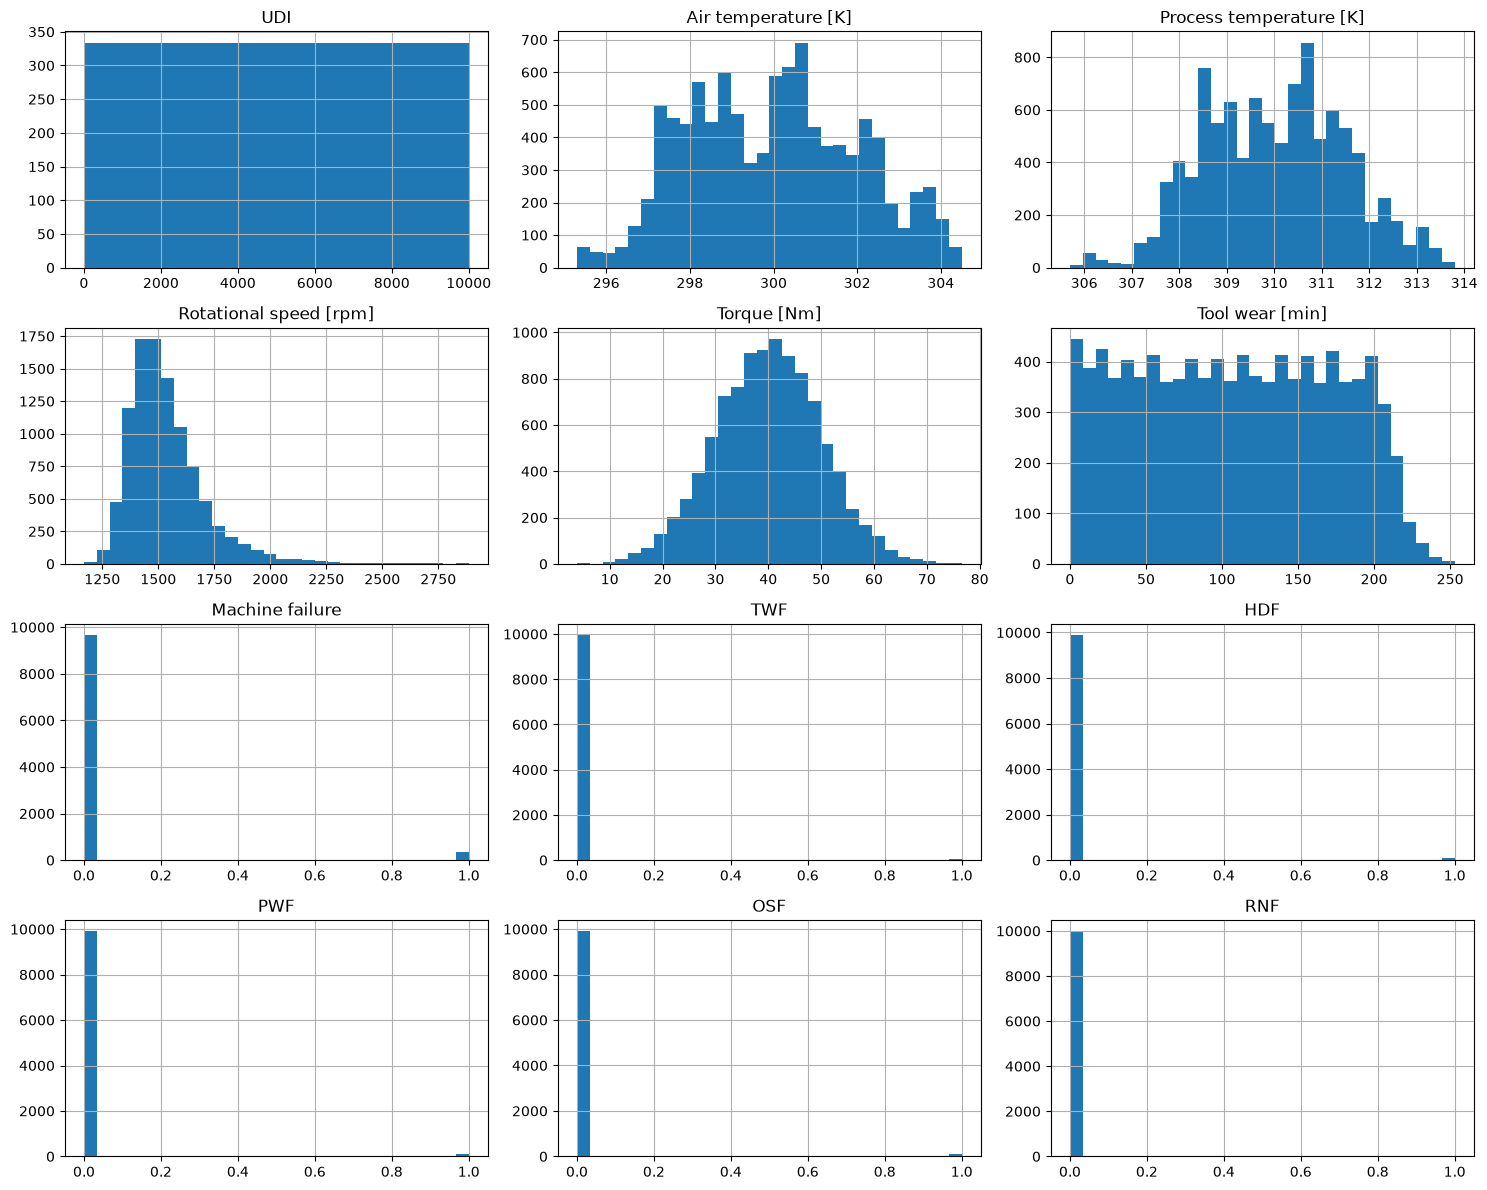

In [20]:
# Numeric distribution 
numeric_cols = df.select_dtypes(include="number").columns.tolist()

numeric_cols

df[numeric_cols].hist(
    bins=30,
    figsize=(15, 12)
)

plt.tight_layout()
plt.show()

# Checkpoint
# 대략 대칭인가?
# 한쪽으로 심하게 치우쳤나?
# 값이 몇 개 구간에만 몰려 있나?
# 긴 꼬리가 있나?
# 특정 값이 압도적으로 많나?

In [21]:
# Low-cardinality column distribution
low_cardinality_cols = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 10
]

low_cardinality_cols

for col in low_cardinality_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- Type ---
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

--- Machine failure ---
Machine failure
0    9661
1     339
Name: count, dtype: int64

--- TWF ---
TWF
0    9954
1      46
Name: count, dtype: int64

--- HDF ---
HDF
0    9885
1     115
Name: count, dtype: int64

--- PWF ---
PWF
0    9905
1      95
Name: count, dtype: int64

--- OSF ---
OSF
0    9902
1      98
Name: count, dtype: int64

--- RNF ---
RNF
0    9981
1      19
Name: count, dtype: int64


In [22]:
# Target distribution
# Target TBA

In [23]:
corr = df.select_dtypes(include="number").corr()

corr.round(2)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,1.00,0.12,0.32,-0.01,0.00,-0.01,-0.02,0.01,-0.02,-0.02,-0.00,-0.01
Air temperature [K],0.12,1.00,0.88,0.02,-0.01,0.01,0.08,0.01,0.14,0.00,0.00,0.02
Process temperature [K],0.32,0.88,1.00,0.02,-0.01,0.01,0.04,0.01,0.06,-0.00,0.00,0.02
Rotational speed [rpm],-0.01,0.02,0.02,1.00,-0.88,0.00,-0.04,0.01,-0.12,0.12,-0.10,-0.01
Torque [Nm],0.00,-0.01,-0.01,-0.88,1.00,-0.00,0.19,-0.01,0.14,0.08,0.18,0.02
Tool wear [min],-0.01,0.01,0.01,0.00,-0.00,1.00,0.11,0.12,-0.00,-0.01,0.16,0.01
Machine failure,-0.02,0.08,0.04,-0.04,0.19,0.11,1.00,0.36,0.58,0.52,0.53,0.00
TWF,0.01,0.01,0.01,0.01,-0.01,0.12,0.36,1.00,-0.01,0.01,0.04,0.03
HDF,-0.02,0.14,0.06,-0.12,0.14,-0.00,0.58,-0.01,1.00,0.02,0.05,-0.00
PWF,-0.02,0.00,-0.00,0.12,0.08,-0.01,0.52,0.01,0.02,1.00,0.12,-0.00


In [24]:
print("=== DATA AUDIT SUMMARY ===")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Missing values: {df.isna().sum().sum():,}")
print(f"Exact duplicate rows: {df.duplicated().sum():,}")
print(f"Numeric columns: {len(df.select_dtypes(include='number').columns)}")
print(f"Categorical columns: {len(df.select_dtypes(include=['object', 'category']).columns)}")

=== DATA AUDIT SUMMARY ===
Rows: 10,000
Columns: 14
Missing values: 0
Exact duplicate rows: 0
Numeric columns: 12
Categorical columns: 2


C:\Users\lma82\AppData\Local\Temp\ipykernel_11112\1109577001.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"Categorical columns: {len(df.select_dtypes(include=['object', 'category']).columns)}")


## Data Audit Findings

### Dataset Structure
- Rows: 10,000
- Columns: 14

### Column Roles Observed During Audit

- Identifier-like:
  - UDI

- Numeric measurement/process variables:
  - Air temperature [K]
  - Process temperature [K]
  - Rotational speed [rpm]
  - Torque [Nm]
  - Tool wear [min]

- Binary indicator columns:
  - Machine failure
  - TWF
  - HDF
  - PWF
  - OSF
  - RNF

### Missing
- 0

### Duplicates
- 0

### Cardinality
- UDI: 각 행을 거의 유일하게 식별하는 high-cardinality 열
- Product ID: high-cardinality 식별자 성격의 열
- Machine failure, TWF, HDF, PWF, OSF, RNF: 각각 0/1의 binary 열
- Constant column: 발견되지 않음

### Distribution observations
- 

### Items requiring later review
1.
2.
3.

### Decisions intentionally NOT made here
- Feature removal
- Preprocessing strategy
- Leakage decision
- Validation design
- Metric selection
- Modeling decision